# Práctica final

## Dataset

In [28]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [29]:
training_set = pd.read_csv('../OffendES_dataset/offendes/train.csv')
print(f"Training set shape: {training_set.shape}, columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('../OffendES_dataset/offendes/test.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (13368, 3), columns: ['comment_id', 'comment', 'label']
Test set shape: (3342, 3), columns: ['comment_id', 'comment', 'label']


In [30]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,comment_id,comment,label
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO
1,21214,Por qué no solamente le diste a una fundación ...,NO
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO
5,41294,"YouTube ya no es como antes, como en esos tiem...",NO
6,33127,Entrar a YouTube después de un día de mierda y...,NOM
7,40612,"Oye y no se puede pagar el curso, hacerlo y de...",NO
8,22418,"Hombre, Javi, se sobreentiende que cuando dice...",NO
9,18623,Lo que habla del hate de él y badabun yo creo ...,NO


In [31]:
# Inspeccionamos el aspecto del conjunto de test
test_set.head(20)

,comment_id,comment,label
0,30327,Eres el mejor Dalas no hagas caso a los haters...,NO
1,32217,La ballena blanca es el único mamífero que a c...,NO
2,799,"Sisi,yo ya estoy harta de él,y pensar que me g...",NO
3,12385,No quiero ser hater ni criticar mira mas abajo...,NO
4,10931,"Lo que dice el Rubius es cierto, mucha gente a...",NO
5,45843,Es el primer video q no me gusta !! Jeje miare...,NO
6,41627,windy por favor >:v deja de gritar me esta la...,NO
7,10540,De aquí a comentar a ese maldito video,NO
8,25087,Te odio BUUUU FALSA,OFP
9,18286,Haz un video opinando de la empresa in cruises...,NO


In [32]:
unique_labels_train = training_set['label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['NO', 'NOM', 'OFP', 'OFG']
Length: 4, dtype: str
Unique labels in test set: <ArrowStringArray>
['NO', 'OFP', 'NOM', 'OFG']
Length: 4, dtype: str


In [33]:
# Mapping dictionary
label_mapping = {
    'OFP': 'Offensive',
    'OFG': 'Offensive',
    'NOM': 'No offensive',
    'NO':  'No offensive'
}

# Apply mapping to create the new column
training_set['joint_label'] = training_set['label'].map(label_mapping)
test_set['joint_label']     = test_set['label'].map(label_mapping)

In [34]:
unique_labels_train = training_set['joint_label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['joint_label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str
Unique labels in test set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str


In [35]:
accepted_labels = {'No offensive', 'Offensive'}
rows_with_problems = training_set[training_set.joint_label.isin(accepted_labels) == False]
rows_with_problems

,comment_id,comment,label,joint_label


In [36]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['comment_id', 'comment', 'label', 'joint_label'], dtype='str')

([0, 1], [Text(0, 0, 'No offensive'), Text(1, 0, 'Offensive')])

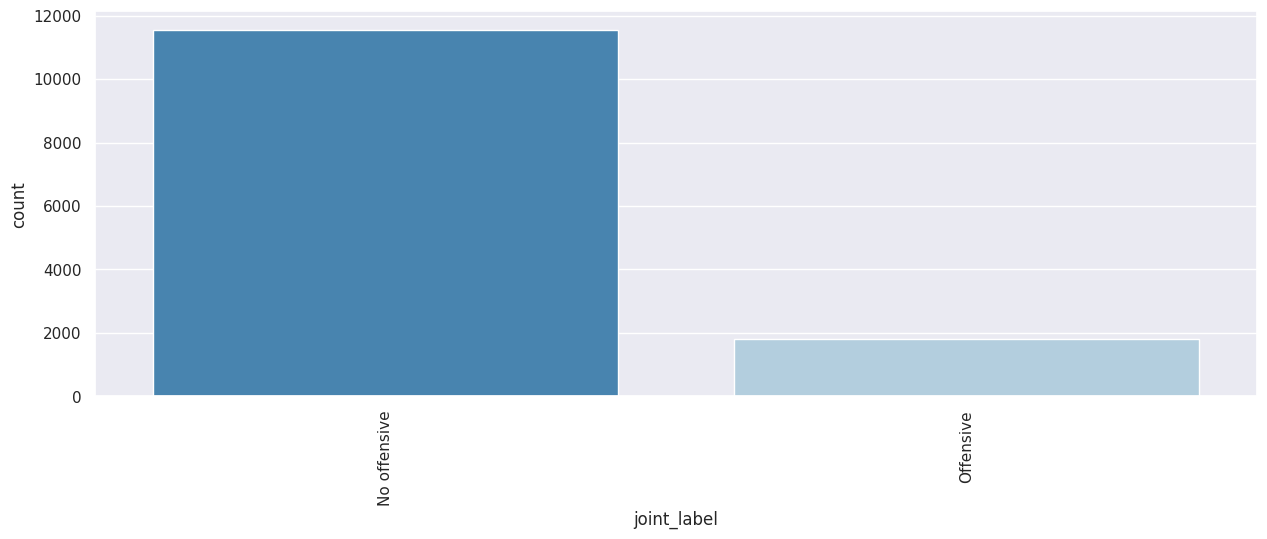

In [37]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.joint_label, order=[x for x, count in sorted(Counter(training_set.joint_label).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

In [38]:
from matplotlib import interactive

# Agrupamos las reviews por su etiqueta
df = pd.DataFrame({"text": training_set.comment, "label": training_set.joint_label})
grouped = df.groupby(['label']).apply(lambda x: x['text'].sum())
grouped_df = pd.DataFrame({'label': grouped.index, 'text': grouped.values})

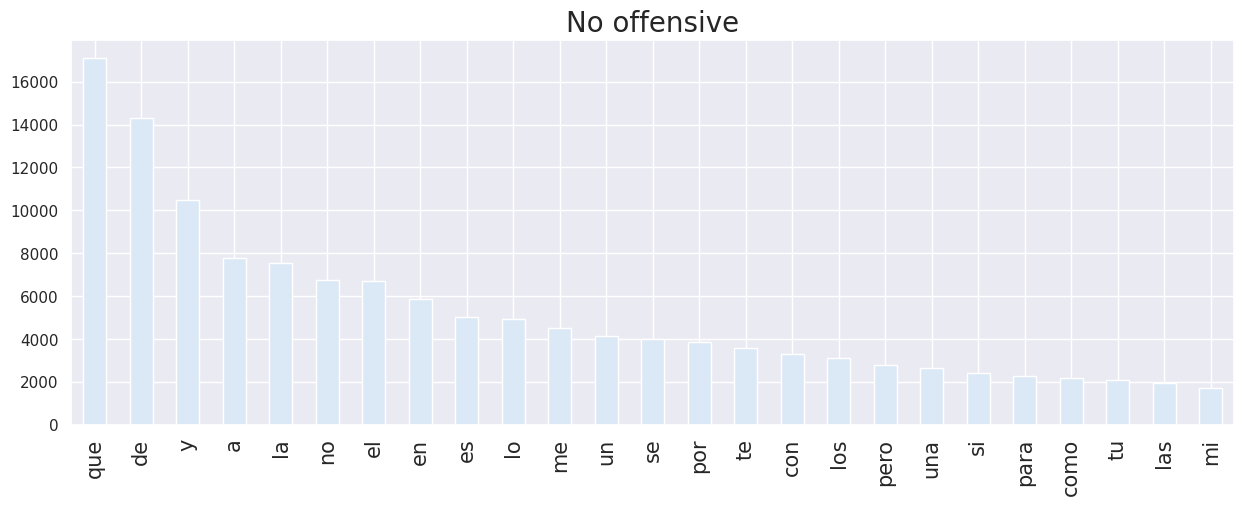

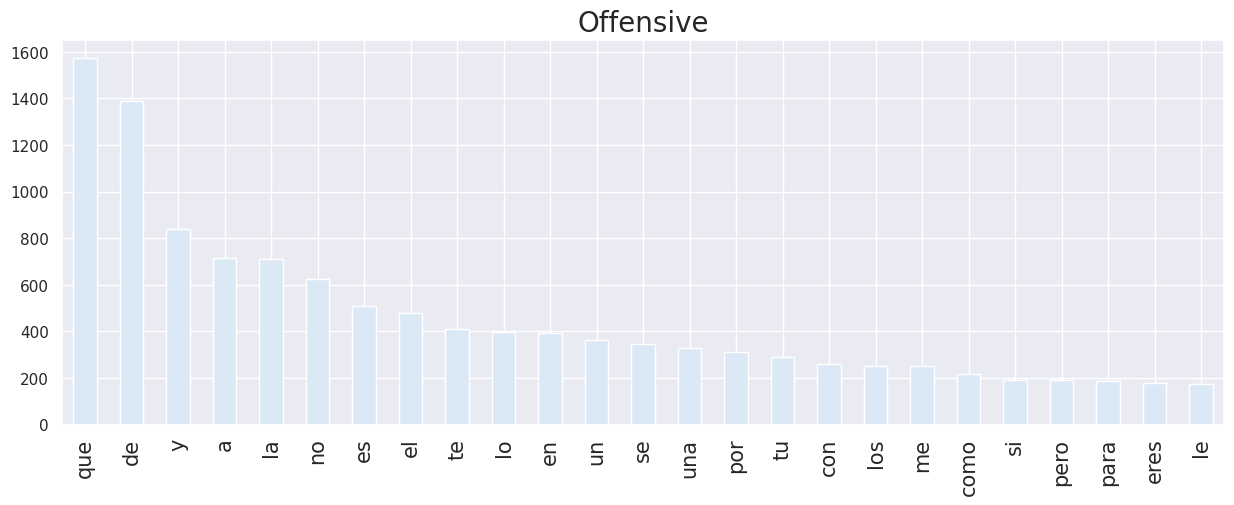

In [39]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    word_counts.plot(kind="bar")
    plt.title(grouped_df.label[ii], fontsize=20)
    plt.xticks(fontsize=15)
    plt.show()

pip install spacy
python -m spacy download es_core_news_sm

In [40]:
import spacy
import unicodedata
import re

# Load Spanish model once (disable unused components for speed)
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
spanish_stopwords = nlp.Defaults.stop_words


def remove_accents(text, keep_enye=True):
    if keep_enye:
        text = text.replace('ñ', '\0n').replace('Ñ', '\0N')
    nfkd = unicodedata.normalize('NFD', text)
    stripped = ''.join(c for c in nfkd if unicodedata.category(c) != 'Mn')
    if keep_enye:
        stripped = stripped.replace('\0n', 'ñ').replace('\0N', 'Ñ')
    return stripped


def process_text(raw_text):
    # Keep letters (with accents) so the lemmatizer works correctly
    pattern = "[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]"
    letters_only = re.sub(pattern, " ", raw_text)

    # Lowercase
    text = letters_only.lower()

    # Lemmatize + remove stopwords with spaCy
    doc = nlp(text)
    lemmas = [
        token.lemma_
        for token in doc
        if token.lemma_ not in spanish_stopwords and token.lemma_.strip()
    ]

    # Remove accents AFTER lemmatization
    lemmas = [remove_accents(lemma) for lemma in lemmas]

    return " ".join(lemmas)

In [41]:
from tqdm import tqdm
tqdm.pandas()

dataset['clean_comment'] = dataset['comment'].progress_apply(lambda x: process_text(x))

100%|██████████| 16710/16710 [00:39<00:00, 420.51it/s]


In [42]:
dataset.head()

,comment_id,comment,label,joint_label,clean_comment
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO,No offensive,da el pregunta retorico turbobo contar el vida...
1,21214,Por qué no solamente le diste a una fundación ...,NO,No offensive,distir fundacion dale mil dolar alguien probab...
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO,No offensive,guapisimo brillante look fantastico video apor...
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO,No offensive,hablar arianar relacionado movida atentado ocu...
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO,No offensive,reviews serie pelis querer empezar serie empez...


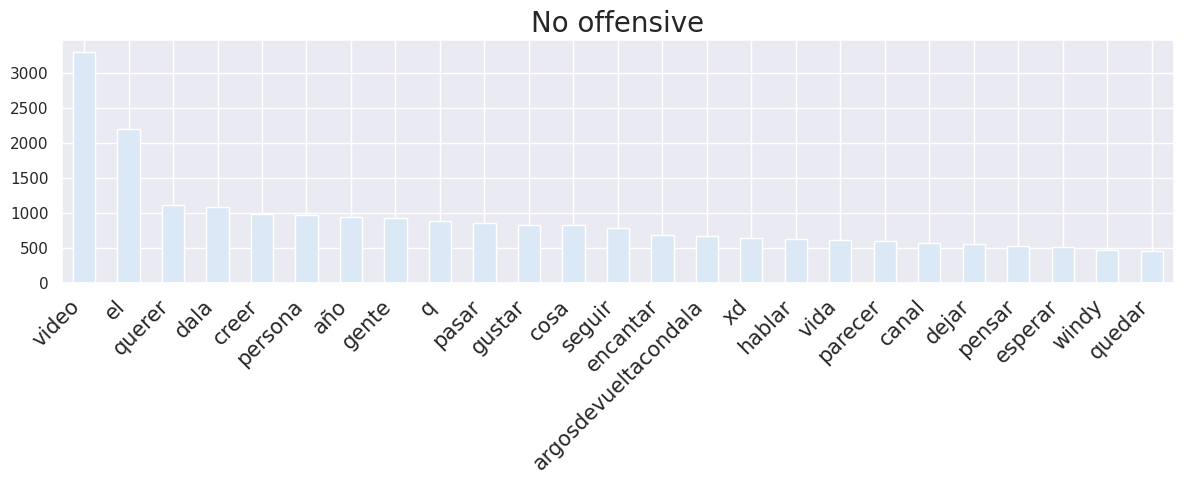

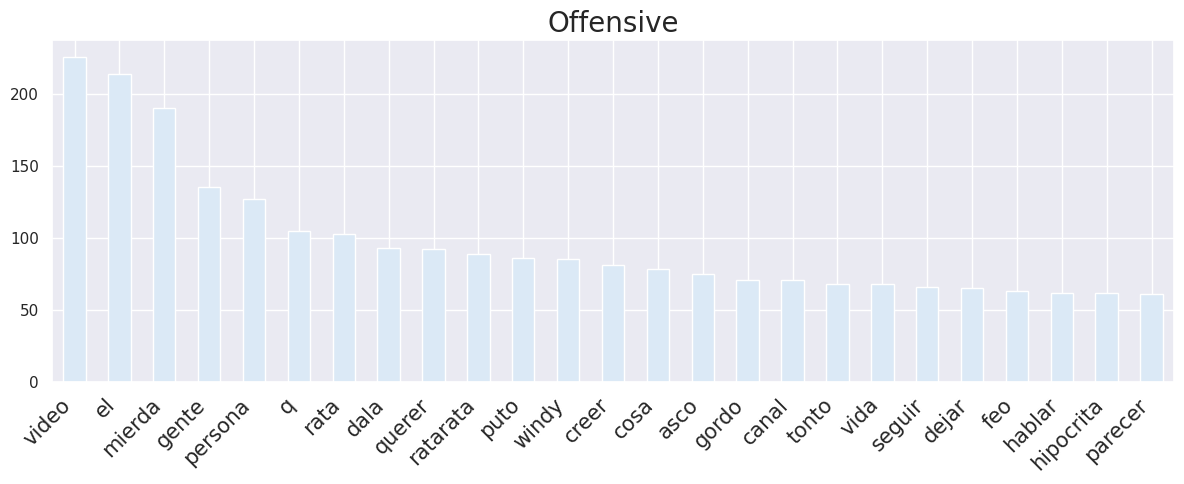

In [43]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "text": dataset[0:len(training_set)].clean_comment,
    "CLASS": dataset[0:len(training_set)].joint_label
})

grouped_df = (
    df.groupby("CLASS")["text"]
      .apply(lambda x: " ".join(x.astype(str)))
      .reset_index()
)

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    plt.figure(figsize=(12, 5))
    word_counts.plot(kind="bar")
    plt.title(grouped_df.CLASS[ii], fontsize=20)
    plt.xticks(fontsize=15, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [44]:
X_train = dataset[0:len(training_set)][["comment_id", "clean_comment"]]
y_train = dataset[0:len(training_set)][["joint_label"]]

X_test = dataset[len(training_set):len(dataset)][["comment_id", "clean_comment"]]
y_test = dataset[len(training_set):len(dataset)][["joint_label"]]

In [45]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.joint_label.values}")
le.fit(y_train.joint_label.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.joint_label.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

Values before encoding: <ArrowStringArray>
['No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive',
 ...
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive']
Length: 13368, dtype: str
Labels after encoding: [0 0 0 ... 0 0 0]
Target labels: ['No offensive' 'Offensive']


In [46]:
print(encoded_y_train)
print(encoded_y_train.shape)

[0 0 0 ... 0 0 0]
(13368,)


In [47]:
count_vect = CountVectorizer(analyzer = "word")

train_features = count_vect.fit_transform(X_train.clean_comment)
test_features = count_vect.transform(X_test.clean_comment)

In [48]:
# Observemos el vocabulario
print('Longitud del vocabulario: ')
print(len(count_vect.vocabulary_))
print()
print("Observemos el vocabulario:")
print(count_vect.vocabulary_)
print()


Longitud del vocabulario: 
22969

Observemos el vocabulario:
{'da': 5406, 'el': 7141, 'pregunta': 16998, 'retorico': 18546, 'turbobo': 21473, 'contar': 4680, 'vida': 22090, 'año': 2148, 'llegar': 12739, 'xdd': 22678, 'distir': 6694, 'fundacion': 9307, 'dale': 5462, 'mil': 13925, 'dolar': 6781, 'alguien': 897, 'probablemente': 17166, 'siquiera': 19740, 'internet': 11343, 'quieres': 17684, 'ayudar': 2105, 'gente': 9517, 'excusa': 8389, 'video': 22102, 'seguidor': 19279, 'guapisimo': 9862, 'brillante': 2797, 'look': 12871, 'fantastico': 8713, 'aportar': 1458, 'hora': 10549, 'ejercicio': 7129, 'beso': 2473, 'hablar': 10021, 'arianar': 1608, 'relacionado': 18260, 'movida': 14336, 'atentado': 1858, 'ocurrio': 15095, 'concierto': 4458, 'pertenecer': 16267, 'mafia': 13047, 'arian': 1606, 'rechazar': 17972, 'titulo': 20971, 'dama': 5475, 'reina': 18235, 'isabel': 11489, 'ofrecer': 15157, 'reviews': 18606, 'serie': 19430, 'pelis': 16017, 'querer': 17640, 'empezar': 7290, 'bola': 2659, 'dejame': 

In [49]:
# Ejemplo original de una review
print("Original:")
print(dataset.comment.head()[0])
print()

# Ejemplo tras el preprocesado
print("Pre-procesado:")
print(X_train.clean_comment[0])
print()

# Convertimos la primera review
v0 = count_vect.transform([X_train.clean_comment[0]]).toarray()[0]
print('Convertido: ')
print(v0)
print()

# Es demasiado grande para observarlo, imprimimos su longitud
print('Longitud del vector: ')
print(len(v0))
print()

# ¿Cuántas palabras contiene la frase?
print('Número de palabras: ')
print(np.sum(v0))
print()


Original:
Dalas: hace una pregunta retórica   Turbobo: *se pone a contarle su vida a partir de los 15 años y de cómo llegó hasta hoy*   Xdd

Pre-procesado:
da el pregunta retorico turbobo contar el vida año llegar xdd

Convertido: 
[0 0 0 ... 0 0 0]

Longitud del vector: 
22969

Número de palabras: 
11



In [50]:
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        scoring='f1_macro',
                        train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and traning learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : integer, cross-validation generator, optional
        If an integer is passed, it is the number of folds (defaults to 3).
        Specific cross-validation objects can be passed, see
        sklearn.cross_validation module for the list of possible objects

    scoring : string, optional
        Scoring metric for the learning curve (default: 'f1_macro').
    """

    plt.figure()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=1, train_sizes=train_sizes,
        scoring=scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend(loc="best")
    plt.grid("on")
    if ylim:
        plt.ylim(ylim)
    plt.title(title)

In [51]:
def train_and_evaluate_classifier(X, yt, estimator, grid):
    """Train and Evaluate a estimator (defined as input parameter) on the given labeled data using F1 Macro."""

    # Se realiza validación cruzada estratificada sobre el clasificador seleccionado
    from sklearn.model_selection import StratifiedShuffleSplit
    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    from sklearn.model_selection import GridSearchCV
    classifier = GridSearchCV(estimator=estimator, cv=cv, param_grid=grid,
                              scoring='f1_macro', error_score=0.0,
                              n_jobs=-1, verbose=5)
    
    # Entrenamiento
    print("Training model")
    classifier.fit(X, yt)

    # Puntuación de la validación cruzada
    print("CV-scores for each grid configuration")
    means = classifier.cv_results_['mean_test_score']
    stds = classifier.cv_results_['std_test_score']
    for mean, std, params in sorted(zip(means, stds, classifier.cv_results_['params']), key=lambda x: -x[0]):
        print("F1 Macro: %0.3f (+/-%0.03f) for params: %r" % (mean, std * 2, params))
    print()
        
    # Curva de aprendizaje
    print("Learning curve for the best estimator")
    title = 'Learning Curves (' + str(estimator.__class__).replace("'>", "").split(".")[-1] + ' )'
    plot_learning_curve(classifier.best_estimator_, title, X, yt, cv=cv)
    plt.show()
    
    return classifier

In [52]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    import itertools
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


# Entrenamiento de algoritmos de aprendizaje automático

### Naive Bayes

Training model
Fitting 5 folds for each of 1 candidates, totalling 5 fits


[CV 1/5] END ..................................., score=0.647 total time=   0.0s
[CV 4/5] END ..................................., score=0.642 total time=   0.0s
[CV 2/5] END ..................................., score=0.668 total time=   0.0s
[CV 3/5] END ..................................., score=0.628 total time=   0.0s
[CV 5/5] END ..................................., score=0.640 total time=   0.0s
CV-scores for each grid configuration
F1 Macro: 0.645 (+/-0.026) for params: {}

Learning curve for the best estimator


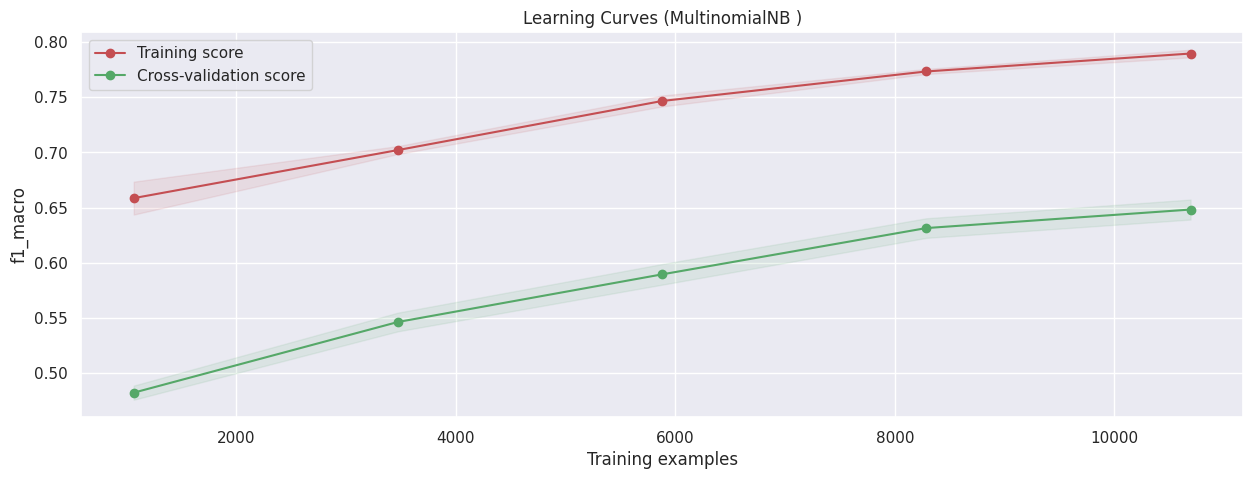

In [53]:
from sklearn.naive_bayes import MultinomialNB

#En este caso no hace falta optimizar ningún parámetro
nb_grid= {} 

nb_text_cls = train_and_evaluate_classifier(train_features, encoded_y_train, MultinomialNB(), nb_grid)

In [54]:
print("Predicting on the test set")
y_pred = nb_text_cls.predict(test_features)

y_pred = le.inverse_transform(y_pred)

Predicting on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.89      0.99      0.94      2889
   Offensive       0.84      0.24      0.37       453

    accuracy                           0.89      3342
   macro avg       0.87      0.62      0.66      3342
weighted avg       0.89      0.89      0.86      3342

Confusion matrix, without normalization


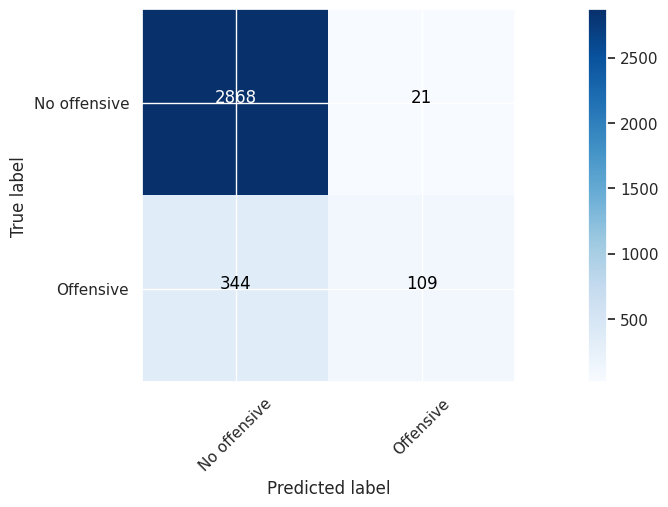

F1 Macro: 0.6571


In [55]:
from sklearn.metrics import f1_score

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## SVM

Training model
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 2/5] END ..............C=100, kernel=linear;, score=0.705 total time=   5.6s
[CV 3/5] END ..............C=100, kernel=linear;, score=0.694 total time=   5.8s
[CV 5/5] END ..............C=100, kernel=linear;, score=0.685 total time=   6.3s
[CV 4/5] END ..............C=100, kernel=linear;, score=0.687 total time=   7.1s
[CV 5/5] END ...............C=10, kernel=linear;, score=0.717 total time=   5.2s
[CV 2/5] END ................C=1, kernel=linear;, score=0.748 total time=   5.5s
[CV 3/5] END ................C=1, kernel=linear;, score=0.750 total time=   5.3s
[CV 1/5] END ................C=1, kernel=linear;, score=0.747 total time=   5.6s
[CV 5/5] END ................C=1, kernel=linear;, score=0.745 total time=   5.7s
[CV 1/5] END ...............C=10, kernel=linear;, score=0.709 total time=   5.3s
[CV 4/5] END ................C=1, kernel=linear;, score=0.736 total time=   5.3s
[CV 2/5] END ...............C=10, 

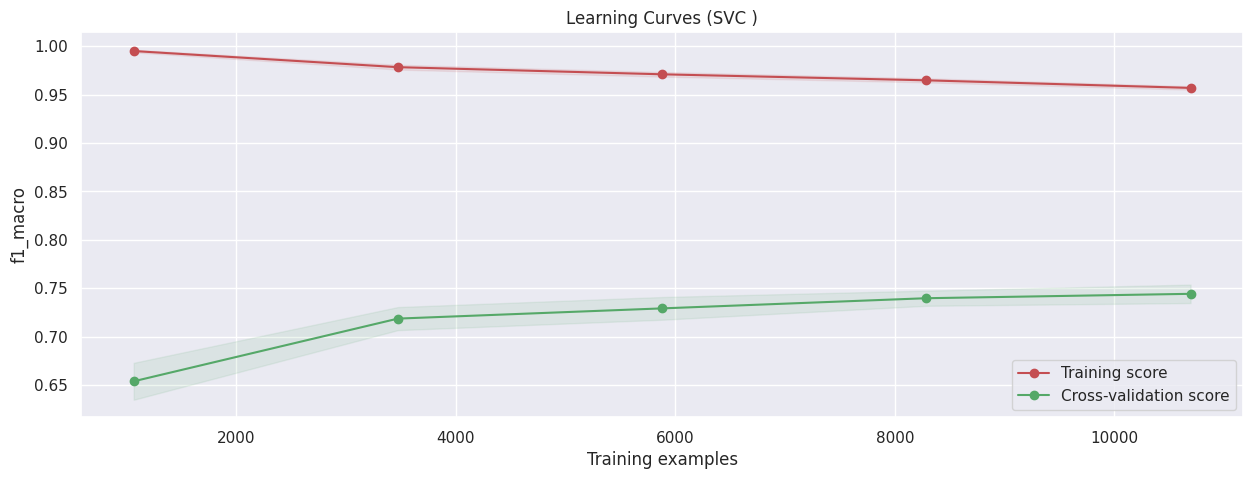

In [56]:
# SVM
from sklearn.svm import SVC

svm_grid = [
  {'C': [1, 10, 100], 'kernel': ['linear']},
  {'C': [10, 100, 1000], 'gamma': [0.0001], 'kernel': ['rbf']},
 ]

svm_cls = train_and_evaluate_classifier(train_features, encoded_y_train, SVC(class_weight='balanced'), svm_grid)

In [57]:
print("Best estimator found by grid search:")
print(svm_cls.best_estimator_)

Best estimator found by grid search:
SVC(C=1, class_weight='balanced', kernel='linear')


In [58]:
print("Predicting sentiment reviews on the test set")
y_pred = svm_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment reviews on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.91      0.92      2889
   Offensive       0.52      0.63      0.57       453

    accuracy                           0.87      3342
   macro avg       0.73      0.77      0.75      3342
weighted avg       0.88      0.87      0.88      3342

Confusion matrix, without normalization


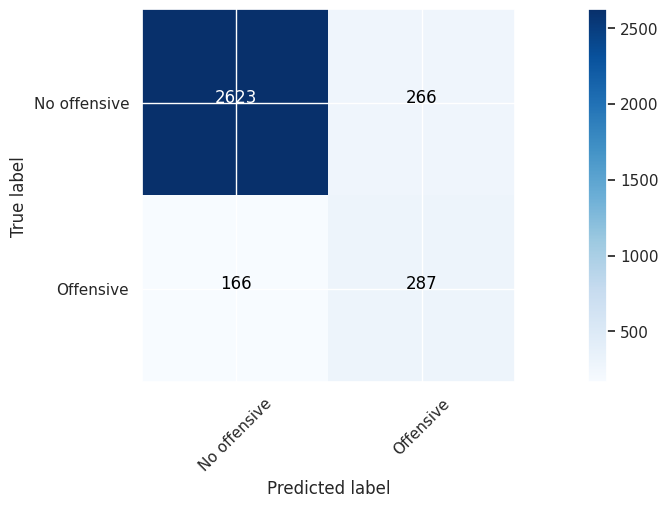

F1 Macro: 0.7472


In [59]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## MaxEnt

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.594 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.585 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.594 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.581 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.603 total time=   0.0s
[CV 2/5] END ................C=0.01, penalty=l1;, score=0.389 total time=   0.0s
[CV 1/5] END ................C=0.

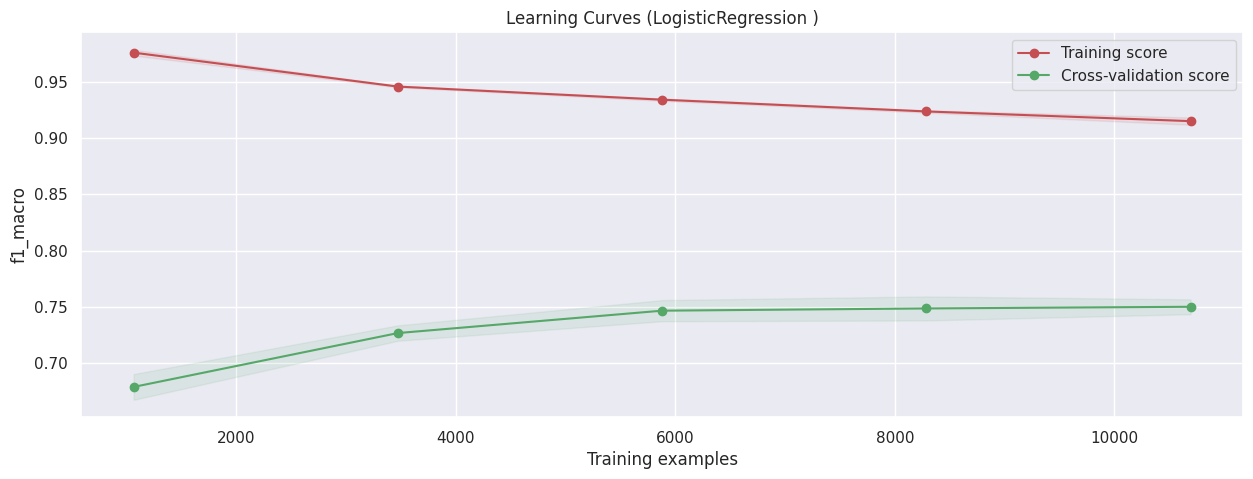

In [60]:
from sklearn.linear_model import LogisticRegression
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [61]:
print("Best estimator found by grid search:")
print(max_ent_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [62]:
print("Predicting sentiment on the test set")
y_pred = max_ent_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.89      0.92      2889
   Offensive       0.51      0.70      0.59       453

    accuracy                           0.87      3342
   macro avg       0.73      0.80      0.76      3342
weighted avg       0.89      0.87      0.88      3342

Confusion matrix, without normalization


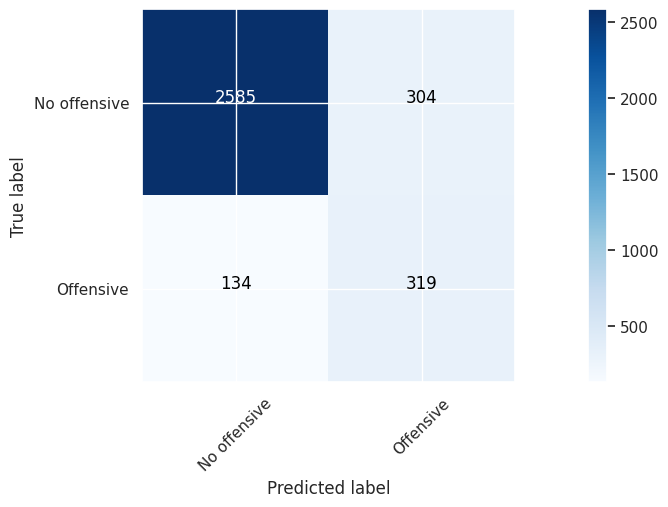

F1 Macro: 0.7574


In [63]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## Pesado con TF-IDF

In [64]:
from sklearn.feature_extraction.text import TfidfTransformer

X_train["all"] = X_train[['clean_comment']].apply(lambda x: ''.join(x), axis=1)
X_test["all"] = X_test[['clean_comment']].apply(lambda x: ''.join(x), axis=1)

count_vect = CountVectorizer(analyzer = "word")
train_features = count_vect.fit_transform(X_train['all'])
test_features = count_vect.transform(X_test['all'])

# Se utiliza L2 (norma euclídea) para normalizar los vectores resultantes
tfidf = TfidfTransformer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(train_features)
test_text_tfidf_features = tfidf.transform(test_features)                


Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.739 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.734 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.729 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.751 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.741 total time=   0.0s
[CV 2/5] END ................C=0.

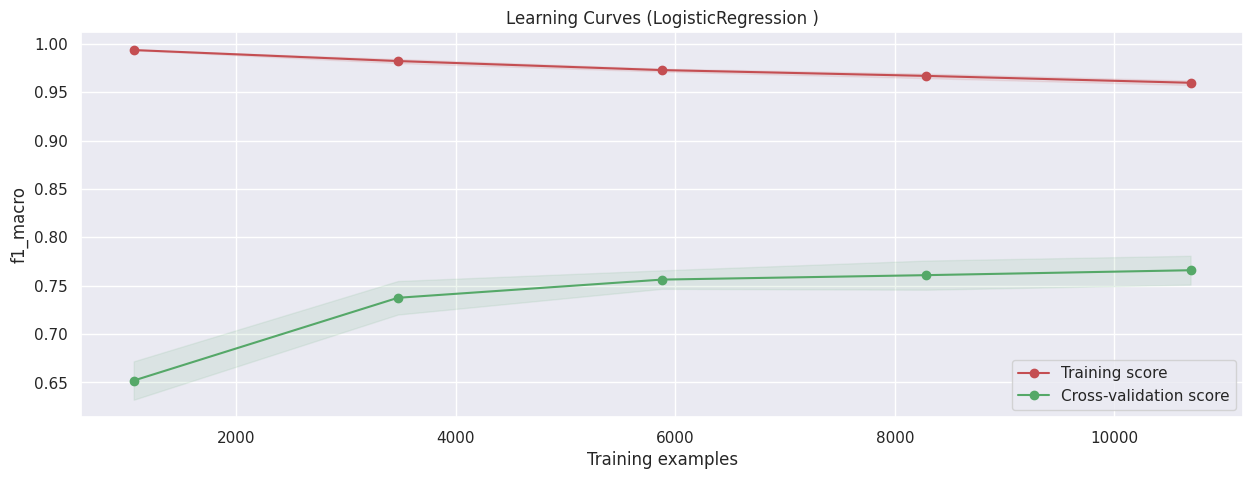

In [65]:
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_tfidf_cls = train_and_evaluate_classifier(train_text_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [66]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=10, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [67]:
print("Predicting sentiment on the test set")
y_pred = max_ent_tfidf_cls.predict(test_text_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.93      0.94      2889
   Offensive       0.59      0.62      0.61       453

    accuracy                           0.89      3342
   macro avg       0.77      0.78      0.77      3342
weighted avg       0.89      0.89      0.89      3342

Confusion matrix, without normalization


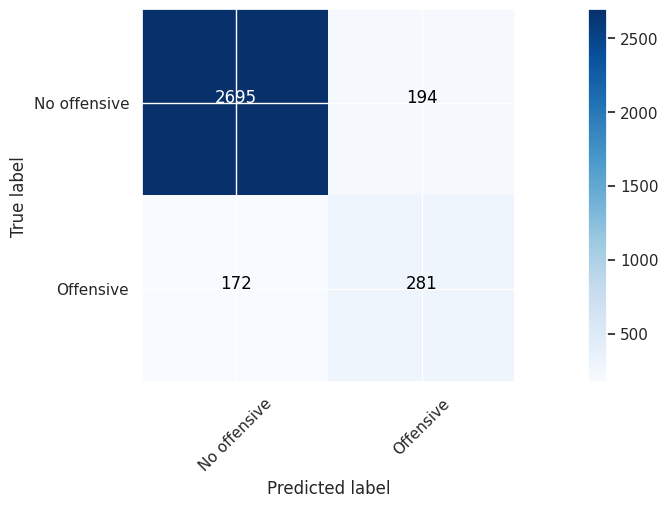

F1 Macro: 0.7710


In [68]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## Bigramas

In [69]:
bigram_count_vect = CountVectorizer(analyzer = "word", ngram_range=(1,2))
train_bigram_features = bigram_count_vect.fit_transform(X_train.clean_comment)
test_bigram_features = bigram_count_vect.transform(X_test.clean_comment)

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.597 total time=   0.3s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.611 total time=   0.3s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.590 total time=   0.3s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.587 total time=   0.3s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.601 total time=   0.3s
[CV 5/5] END ................C=0.01, penalty=l1;, score=0.403 total time=   0.4s
[CV 3/5] END ................C=0.

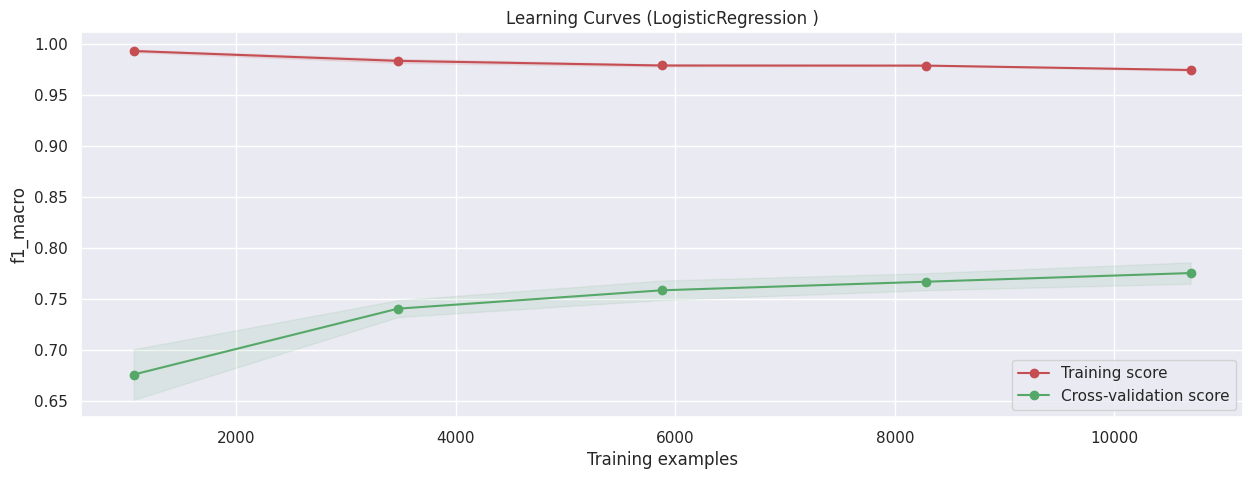

In [70]:
max_ent_bigram_cls = train_and_evaluate_classifier(train_bigram_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [71]:
print("Best estimator found by grid search:")
print(max_ent_bigram_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [72]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_cls.predict(test_bigram_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.93      0.94      2889
   Offensive       0.60      0.63      0.62       453

    accuracy                           0.89      3342
   macro avg       0.77      0.78      0.78      3342
weighted avg       0.90      0.89      0.89      3342

Confusion matrix, without normalization


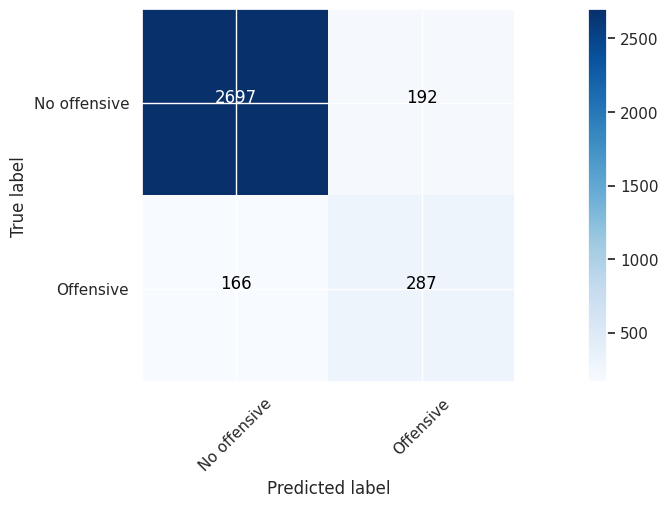

F1 Macro: 0.7768


In [73]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## Bigramas con TF-IDF

In [74]:
tfidf = TfidfTransformer(norm="l2")
train_text_bigram_tfidf_features = tfidf.fit_transform(train_bigram_features)
test_text_bigram_tfidf_features = tfidf.fit_transform(test_bigram_features)    

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 2/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.1s
[CV 5/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.1s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.1s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.736 total time=   0.1s[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.753 total time=   0.1s
[CV 1/5] END ...............C=0.00

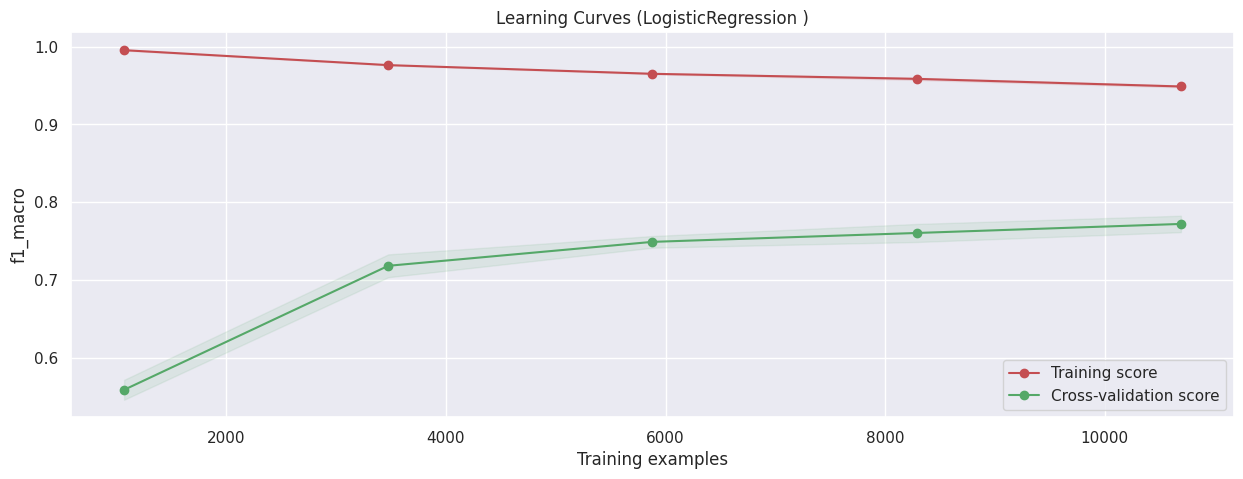

In [75]:
max_ent_bigram_tfidf_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [76]:
print("Best estimator found by grid search:")
print(max_ent_bigram_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [77]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_tfidf_cls.predict(test_text_bigram_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.92      0.93      2889
   Offensive       0.58      0.68      0.62       453

    accuracy                           0.89      3342
   macro avg       0.76      0.80      0.78      3342
weighted avg       0.90      0.89      0.89      3342

Confusion matrix, without normalization


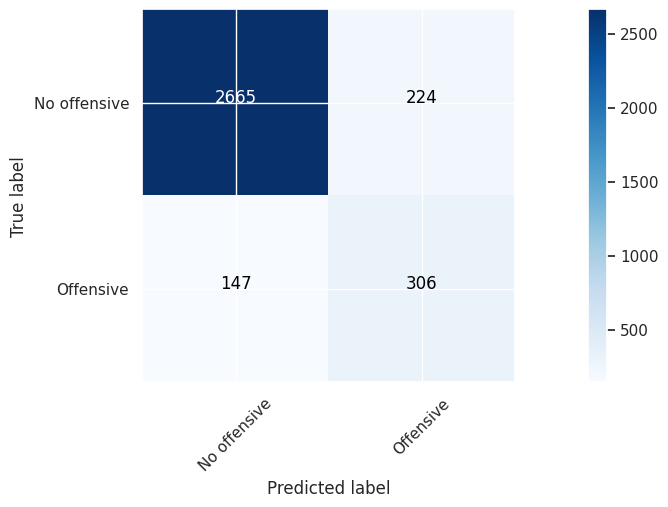

F1 Macro: 0.7788


In [78]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

In [79]:
def most_informative_feature_for_binary_classification(vectorizer, classifier, n=100):
    """
    See: https://stackoverflow.com/a/26980472
    
    Identify most important features if given a vectorizer and binary classifier. Set n to the number
    of weighted features you would like to show. (Note: current implementation merely prints and does not 
    return top classes.)
    """

    class_labels = classifier.classes_
    feature_names = vectorizer.get_feature_names_out()
    topn_class1 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: u[1])[:n]
    topn_class2 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: -u[1])[:n]

    return topn_class1, topn_class2

In [80]:
# Remember negative is index 0 and positive is index 1
negative_features, positive_features = most_informative_feature_for_binary_classification(bigram_count_vect, max_ent_cls.best_estimator_, n=30)

<Axes: title={'center': 'Most important features to identify negative reviews'}, xlabel='feature'>

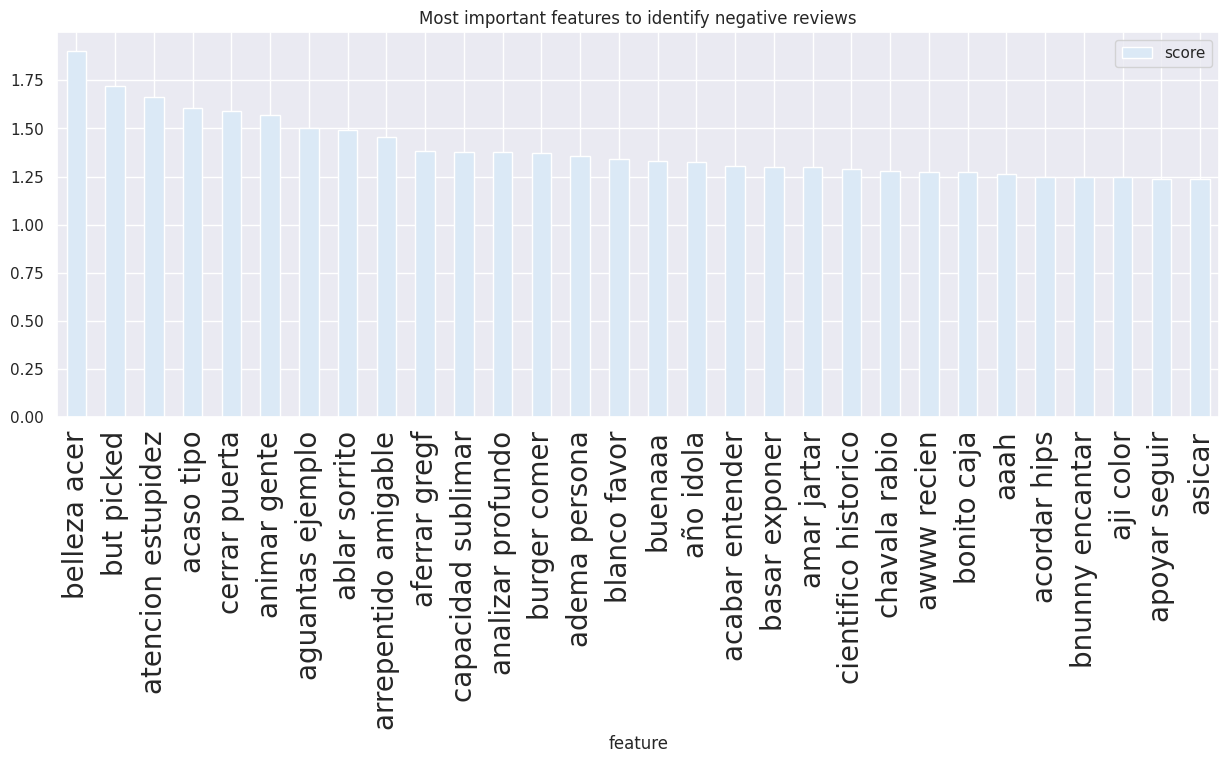

In [81]:
top_negative_features = pd.DataFrame(negative_features, columns=["feature", "score"])
top_negative_features.score = abs(top_negative_features.score)
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_negative_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify negative reviews")

<Axes: title={'center': 'Most important features to identify positive reviews'}, xlabel='feature'>

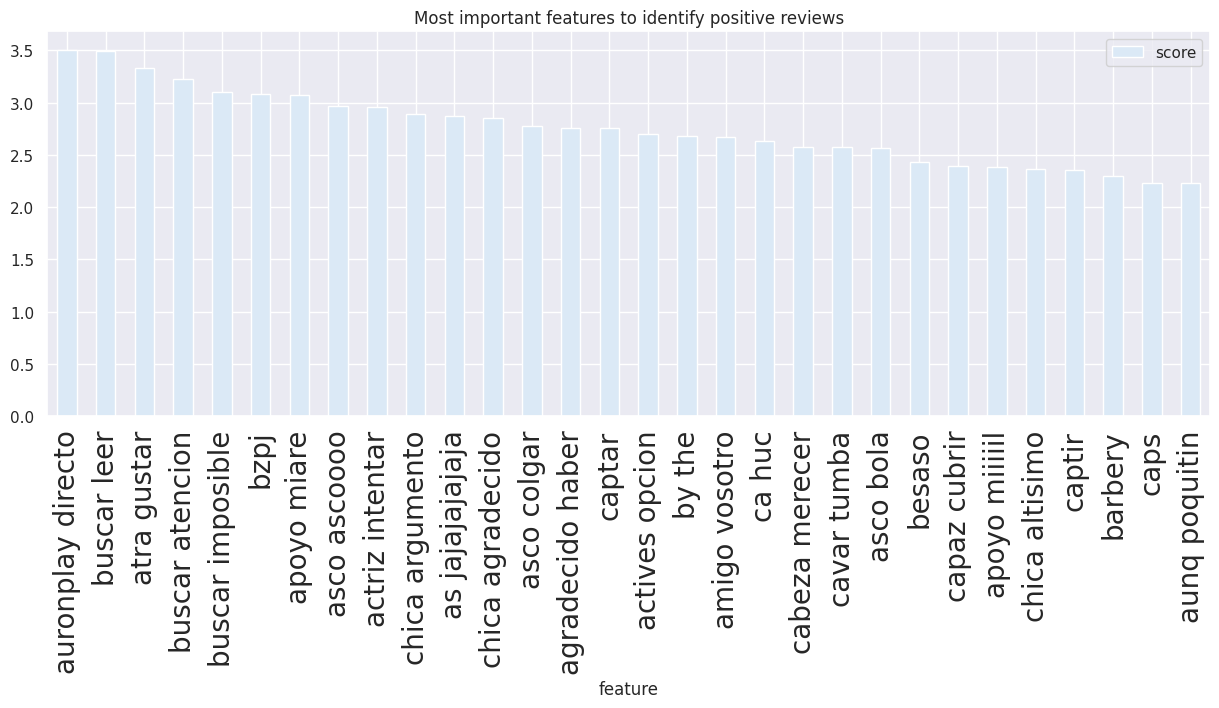

In [82]:
top_positive_features = pd.DataFrame(positive_features, columns=["feature", "score"])
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_positive_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify positive reviews")

## Bigramas con TF-IDF y reducción de características a 5000

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.739 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.759 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.751 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.734 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.736 total time=   0.0s
[CV 2/5] END ................C=0.

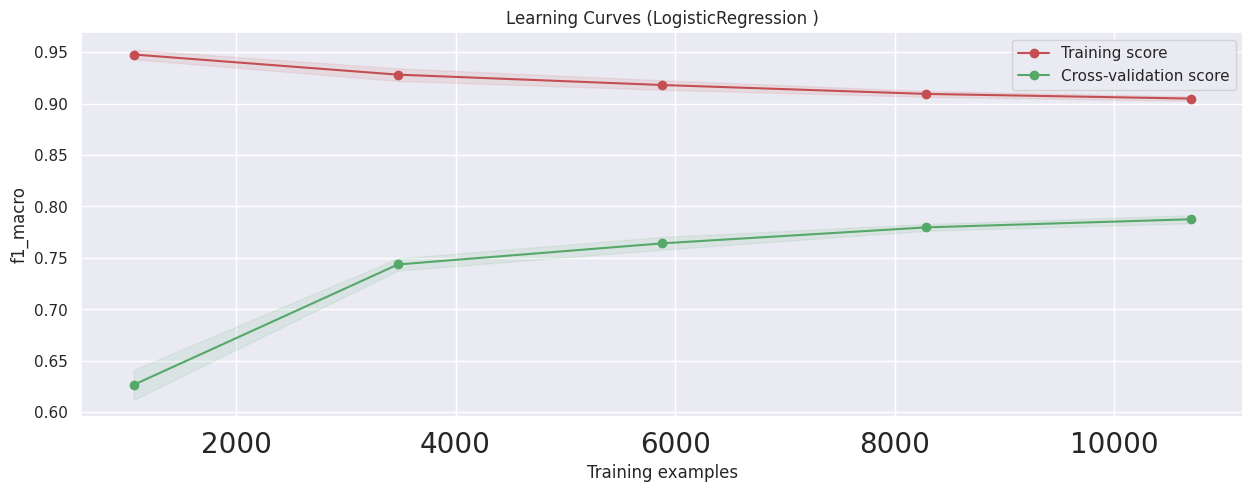

In [83]:
bigram_tfidf_chi2_vect = TfidfVectorizer(norm="l2", ngram_range=(1,2))
train_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.fit_transform(X_train.clean_comment)
test_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.transform(X_test.clean_comment)

ch2 = SelectKBest(chi2, k=5000)
train_text_bigram_tfidf_chi2_features = ch2.fit_transform(train_text_bigram_tfidf_chi2_features, y_train)
test_text_bigram_tfidf_chi2_features = ch2.transform(test_text_bigram_tfidf_chi2_features)

max_ent_bigram_tfidf_chi2_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_chi2_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

Predicting sentiment on the test set
Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.92      0.93      2889
   Offensive       0.56      0.67      0.61       453

    accuracy                           0.89      3342
   macro avg       0.76      0.79      0.77      3342
weighted avg       0.89      0.89      0.89      3342

Confusion matrix, without normalization


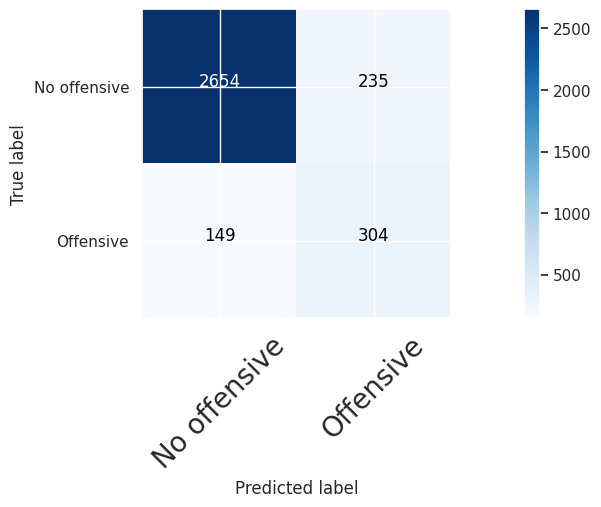

F1 Macro: 0.7727


In [84]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_tfidf_chi2_cls.predict(test_text_bigram_tfidf_chi2_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

# Resumen de Experimentos

| Representación + Algoritmo | F1 Macro |
|---|---|
| BoW (unigramas) + Naive Bayes | 0.6571 |
| BoW (unigramas) + SVM lineal | 0.7472 |
| BoW (unigramas) + Regresión Logística (MaxEnt) | 0.7574 |
| TF-IDF (unigramas) + Regresión Logística (MaxEnt) | 0.7710 |
| BoW (uni+bigramas) + Regresión Logística (MaxEnt) | 0.7768 |
| TF-IDF (uni+bigramas) + Regresión Logística (MaxEnt) | 0.7788 |
| TF-IDF (uni+bigramas) + Chi² (k=5000) + Regresión Logística (MaxEnt) | 0.7727 |

# Neural Networks MLP

## Utilidades

In [85]:
# Importamos capas densas, capas de embeddings y capas para el aplanaEl hecho de que de una manera se pueda explicar el resultado del modelo ayuda do de dimensiones
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [86]:
def print_model_info(model):
    print("=" * 80)
    print("MODEL ARCHITECTURE")
    print("=" * 80)
    print(model)
    print()
    
    print("=" * 80)
    print("MODEL PARAMETERS")
    print("=" * 80)
    
    total_params = 0
    trainable_params = 0
    
    print(f"{'Layer':<40} {'Parameters':<15} {'Shape':<20}")
    print("-" * 80)
    
    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        if param.requires_grad:
            trainable_params += num_params
        
        print(f"{name:<40} {num_params:<15,} {str(list(param.shape)):<20}")
    
    print("-" * 80)
    print(f"{'Total Parameters:':<40} {total_params:,}")
    print(f"{'Trainable Parameters:':<40} {trainable_params:,}")
    print(f"{'Non-trainable Parameters:':<40} {(total_params - trainable_params):,}")
    
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / 1024**2
    
    print(f"{'Model Size:':<40} {size_mb:.2f} MB")
    print("=" * 80)

In [87]:
# Con esta función podremos ver cómo evoluciona el entrenamiento y la validación de los modelos.

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Clase similar a la estructura que se obtiene al entrenar los modelos en tf.keras
class History:
    def __init__(self):
        self.history = {
            'loss': [],
            'acc': [],
            'val_loss': [],
            'val_acc': []
        }

def plot_history(history, metric='acc'):
    acc = history.history[metric]
    val_acc = history.history[f'val_{metric}']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

In [88]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

def _is_binary_criterion(criterion):
    """Binary criteria expect float targets of shape [N, 1]."""
    return (
        isinstance(criterion, (nn.BCELoss, nn.BCEWithLogitsLoss))
        or getattr(criterion, 'expects_float_targets', False)
    )

def train_pytorch_model(
    model,
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    optimizer=None,
    criterion=None,
    device=None,
    patience=5,
    scheduler=None
):    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    # Se mueve el modelo al device (CPU o GPU)
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    is_text_data = isinstance(X_train, torch.Tensor) and X_train.dtype == torch.long

    if hasattr(X_train, 'toarray'):
        X_train = X_train.toarray()

    if not isinstance(X_train, torch.Tensor):
        if is_text_data or X_train.dtype in [np.int32, np.int64]:
            X_train = torch.LongTensor(np.array(X_train))
        else:
            X_train = torch.FloatTensor(np.array(X_train).astype('float32'))

    if _is_binary_criterion(criterion):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))
    elif isinstance(criterion, nn.CrossEntropyLoss):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.LongTensor(np.array(y_train))
    else:
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))

    # Train/validation split
    if validation_split > 0:
        X_numpy = X_train.numpy() if isinstance(X_train, torch.Tensor) else X_train
        y_numpy = y_train.numpy() if isinstance(y_train, torch.Tensor) else y_train
        
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_numpy, y_numpy, test_size=validation_split, random_state=42
        )

        if X_train.dtype == torch.long:
            X_train_split = torch.LongTensor(X_train_split)
            X_val_split = torch.LongTensor(X_val_split)
        else:
            X_train_split = torch.FloatTensor(X_train_split)
            X_val_split = torch.FloatTensor(X_val_split)

        if y_train.dtype == torch.long:
            y_train_split = torch.LongTensor(y_train_split)
            y_val_split = torch.LongTensor(y_val_split)
        else:
            y_train_split = torch.FloatTensor(y_train_split)
            y_val_split = torch.FloatTensor(y_val_split)
    else:
        X_train_split, y_train_split = X_train, y_train
        X_val_split, y_val_split = None, None

    if _is_binary_criterion(criterion) and y_train_split.dim() == 1:
        y_train_split = y_train_split.unsqueeze(1)
        if validation_split > 0:
            y_val_split = y_val_split.unsqueeze(1)

    # Los datasets son directamente TensorDataset de Pytorch
    train_dataset = TensorDataset(X_train_split, y_train_split)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    if validation_split > 0:
        val_dataset = TensorDataset(X_val_split, y_val_split)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Inicializar el histórico
    history = History()

    # Rutina de entrenamiento
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            if isinstance(criterion, nn.CrossEntropyLoss):
                predicted = torch.argmax(outputs, dim=1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            else:
                predicted = (outputs > 0.5).float()
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()

        # Métricas de entrenamiento: Train loss, train accuracy
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total
        history.history['loss'].append(epoch_train_loss)
        history.history['acc'].append(epoch_train_acc)

        if validation_split > 0:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            # Modelo en modo inferencia sin guardar los gradientes
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()

                    if isinstance(criterion, nn.CrossEntropyLoss):
                        predicted = torch.argmax(outputs, dim=1)
                    else:
                        predicted = (outputs > 0.5).float()

                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()

            epoch_val_loss = val_loss / len(val_loader)
            epoch_val_acc = val_correct / val_total
            history.history['val_loss'].append(epoch_val_loss)
            history.history['val_acc'].append(epoch_val_acc)

            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(epoch_val_loss)
                else:
                    scheduler.step()
                print(f"Stepping learning rate to value: {scheduler.get_lr()}")

            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                patience_counter = 0
                # Guardar mejor modelo
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
                print(f" (patience: {patience_counter}/{patience})")

            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                # Restaurar mejor modelo
                model.load_state_dict(best_model_state)
                break
        else:
            history.history['val_loss'].append(0.0)
            history.history['val_acc'].append(0.0)

        if validation_split > 0:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f} - '
                  f'val_loss: {epoch_val_loss:.4f} - '
                  f'val_acc: {epoch_val_acc:.4f}')
        else:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f}')

    return history


In [89]:
def evaluate_pytorch_model(model, X_test, y_test, le=None, target_labels=None, device=None, batch_size=32):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval()

    if hasattr(X_test, 'toarray'):
        X_test_array = X_test.toarray().astype('float32')
        X_test_tensor = torch.FloatTensor(X_test_array)
    elif isinstance(X_test, torch.Tensor):
        X_test_tensor = X_test.cpu()
    else:
        X_test_array = np.array(X_test)
        if X_test_array.dtype in [np.int32, np.int64]:
            X_test_tensor = torch.LongTensor(X_test_array)
        else:
            X_test_tensor = torch.FloatTensor(X_test_array.astype('float32'))

    if isinstance(y_test, torch.Tensor):
        y_test = y_test.cpu().numpy()
    else:
        y_test = np.array(y_test)

    from torch.utils.data import TensorDataset, DataLoader

    dataset = TensorDataset(X_test_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_predictions = []

    with torch.no_grad():
        # En algunos entrenamientos con CNN, pasar como en la prácica anterior un batch del tamaño del test set
        # hacia que la GPU se quedara sin memoria, por eso paso un mini batch. Los resultados de 
        # evaluación deberían ser los mismos.
        for batch in dataloader:
            batch_X = batch[0].to(device)
            outputs = model(batch_X).cpu()
            
            if outputs.shape[1] == 1:
                # Si la salida es tamaño 1, como mencionado anteriormente, se usa un threshold
                # en 0.5 para diferenciar entre una clase u otra
                batch_pred = (outputs.numpy() > 0.5).astype(int).flatten()
            else:
                # Si la salida es de tamaño > 1, entonces la clase escogida
                # es aquella que tenga la probabilidad más alta (por eso argmax)
                batch_pred = torch.argmax(outputs, dim=1).numpy()
            
            all_predictions.append(batch_pred)
    
    y_pred = np.concatenate(all_predictions)
    
    if le is not None:
        y_pred_labels = le.inverse_transform(y_pred)
        if y_test.dtype in [np.int32, np.int64]:
            y_test_labels = le.inverse_transform(y_test)
        else:
            y_test_labels = y_test
    else:
        y_pred_labels = y_pred
        y_test_labels = y_test
    
    if target_labels is None:
        unique_labels = np.unique(np.concatenate([y_test_labels, y_pred_labels]))
        target_labels = sorted(unique_labels)
    
    print("Classification Report")
    print(classification_report(y_test_labels, y_pred_labels, target_names=target_labels))
    cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_labels)
    plot_confusion_matrix(cm, classes=target_labels)
    print("F1 Macro: %.4f" % f1_score(y_test_labels, y_pred_labels, average='macro'))
    
    return y_pred_labels

In [90]:
#Número de épocas (iteraciones globales)
epochs = 40
#Dimensión de la capa de embeddings
emb_dim = 50
#Tamaño de batch (lote)
batch_size = 32
#Número de palabras tenidas en cuenta (reducción del vocabulario)
n_most_common_words = 50000
#Máxima longitud del documento
max_len = 512

## Entrenamiento de modelos MLP con representación TF-IDF

In [91]:
Y_train = encoded_y_train  # Shape: (n_samples,)
Y_test = le.transform(y_test.values)

print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(Y_train[0:10])

Y_train shape: (13368,)
Y_test shape: (3342,)
[0 0 0 0 0 0 0 0 0 0]


In [92]:
class BinaryClassifierMLP(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifierMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        # Single output neuron
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.softmax(x, dim=1)

        x = self.fc2(x)
        x = F.softmax(x, dim=1)
        
        x = self.fc3(x)
        x = F.sigmoid(x)

        return x

In [93]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierMLP(input_dim)
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierMLP(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        2,948,4

Epoch 1/40 - loss: 0.6251 - acc: 0.7429 - val_loss: 0.5378 - val_acc: 0.8598
Epoch 2/40 - loss: 0.4802 - acc: 0.8658 - val_loss: 0.4467 - val_acc: 0.8598
Epoch 3/40 - loss: 0.4195 - acc: 0.8658 - val_loss: 0.4145 - val_acc: 0.8598
Epoch 4/40 - loss: 0.3982 - acc: 0.8658 - val_loss: 0.4041 - val_acc: 0.8598
Epoch 5/40 - loss: 0.3857 - acc: 0.8658 - val_loss: 0.3908 - val_acc: 0.8598
Epoch 6/40 - loss: 0.3557 - acc: 0.8658 - val_loss: 0.3593 - val_acc: 0.8598
Epoch 7/40 - loss: 0.3040 - acc: 0.8658 - val_loss: 0.3262 - val_acc: 0.8598
Epoch 8/40 - loss: 0.2510 - acc: 0.8658 - val_loss: 0.3027 - val_acc: 0.8598
Epoch 9/40 - loss: 0.2079 - acc: 0.8898 - val_loss: 0.2905 - val_acc: 0.8983
Epoch 10/40 - loss: 0.1745 - acc: 0.9433 - val_loss: 0.2860 - val_acc: 0.9065
 (patience: 1/5)
Epoch 11/40 - loss: 0.1507 - acc: 0.9545 - val_loss: 0.2876 - val_acc: 0.9043
 (patience: 2/5)
Epoch 12/40 - loss: 0.1326 - acc: 0.9598 - val_loss: 0.2912 - val_acc: 0.8998
 (patience: 3/5)
Epoch 13/40 - loss: 0.

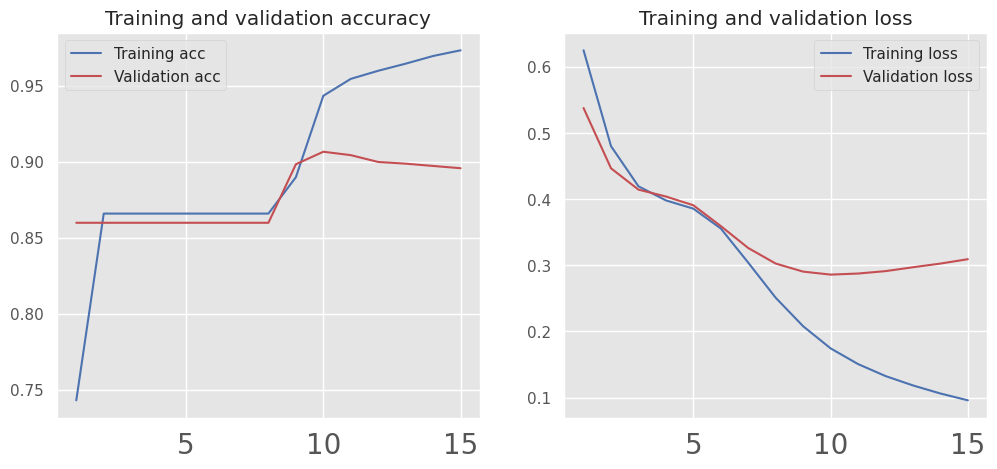

In [94]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.95      0.94      2889
   Offensive       0.64      0.52      0.58       453

    accuracy                           0.90      3342
   macro avg       0.79      0.74      0.76      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


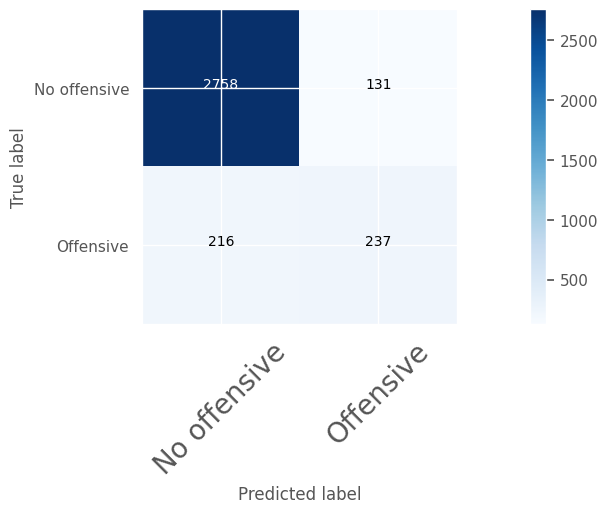

F1 Macro: 0.7591


In [95]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

## MLP con class-weighted loss (BCEWithLogitsLoss)

In [96]:
class BinaryClassifierMLPLogits(nn.Module):
    """Igual que BinaryClassifierMLP pero sin sigmoid final.
    BCEWithLogitsLoss aplica sigmoid internamente, aplicarlo dos veces daría resultados erróneos."""
    def __init__(self, input_dim):
        super(BinaryClassifierMLPLogits, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.softmax(self.fc1(x), dim=1)
        x = F.softmax(self.fc2(x), dim=1)
        return self.fc3(x)

# pos_weight = nº muestras negativas / nº muestras positivas
n_neg = (Y_train == 0).sum()
n_pos = (Y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"Clase 0 (No offensive): {n_neg} | Clase 1 (Offensive): {n_pos} | pos_weight: {pos_weight.item():.2f}")

input_dim = train_text_tfidf_features.shape[1]
model_weighted = BinaryClassifierMLPLogits(input_dim).to(device)
print_model_info(model_weighted)

Clase 0 (No offensive): 11558 | Clase 1 (Offensive): 1810 | pos_weight: 6.39
MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
----------------------------------------------

Epoch 1/40 - loss: 1.1934 - acc: 0.8658 - val_loss: 1.2171 - val_acc: 0.8598
Epoch 2/40 - loss: 1.1942 - acc: 0.8658 - val_loss: 1.2164 - val_acc: 0.8598
Epoch 3/40 - loss: 1.1925 - acc: 0.8658 - val_loss: 1.2101 - val_acc: 0.8598
Epoch 4/40 - loss: 1.1619 - acc: 0.8658 - val_loss: 1.1620 - val_acc: 0.8598
Epoch 5/40 - loss: 1.0484 - acc: 0.8670 - val_loss: 1.0541 - val_acc: 0.8751
Epoch 6/40 - loss: 0.8723 - acc: 0.9171 - val_loss: 0.9527 - val_acc: 0.8987
Epoch 7/40 - loss: 0.7049 - acc: 0.9380 - val_loss: 0.8898 - val_acc: 0.8904
Epoch 8/40 - loss: 0.5517 - acc: 0.9392 - val_loss: 0.8605 - val_acc: 0.8829
 (patience: 1/5)
Epoch 9/40 - loss: 0.4337 - acc: 0.9447 - val_loss: 0.8843 - val_acc: 0.8841
 (patience: 2/5)
Epoch 10/40 - loss: 0.3568 - acc: 0.9514 - val_loss: 0.9267 - val_acc: 0.8818
 (patience: 3/5)
Epoch 11/40 - loss: 0.2969 - acc: 0.9575 - val_loss: 0.9779 - val_acc: 0.8844
 (patience: 4/5)
Epoch 12/40 - loss: 0.2546 - acc: 0.9627 - val_loss: 1.0489 - val_acc: 0.8863
 (pat

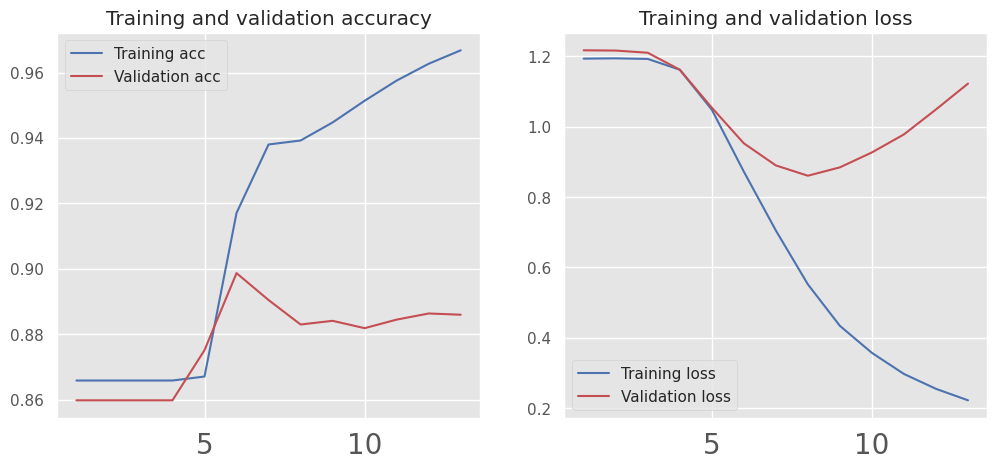

In [97]:
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
history_weighted = train_pytorch_model(
    model_weighted,
    train_text_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_weighted.parameters(), lr=0.001),
    criterion=criterion_weighted,
    patience=5,
    device=device)
plot_history(history_weighted)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.93      0.93      2889
   Offensive       0.57      0.57      0.57       453

    accuracy                           0.88      3342
   macro avg       0.75      0.75      0.75      3342
weighted avg       0.88      0.88      0.88      3342

Confusion matrix, without normalization


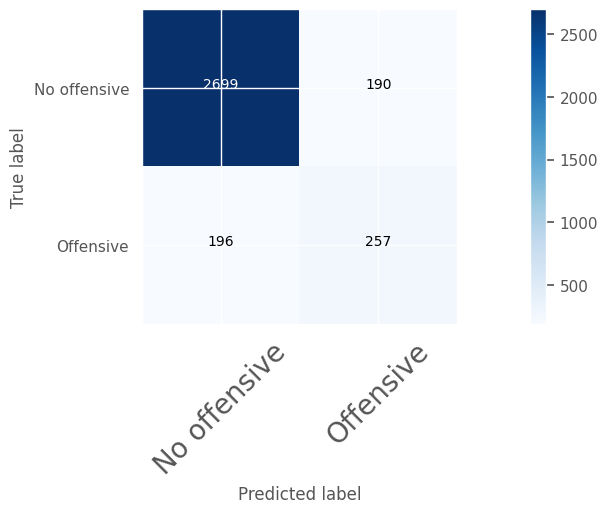

F1 Macro: 0.7522


In [98]:
y_pred_weighted = evaluate_pytorch_model(model_weighted, test_text_tfidf_features, Y_test, le, target_labels, device)

## MLP con Focal Loss

In [99]:
class FocalLoss(nn.Module):
    """Focal Loss para clasificación binaria con logits (Lin et al., 2017).
    
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    
    alpha: peso para la clase positiva (Offensive). Valores altos penalizan
           más los falsos negativos. Típicamente 0.25 o n_neg/n_total.
    gamma: parámetro de enfoque. Reduce el peso de ejemplos fáciles (bien
           clasificados) para que el modelo se centre en los difíciles.
           gamma=0 equivale a BCE estándar. Típicamente 2.0.
    """
    expects_float_targets = True  # marca para train_pytorch_model

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        p = torch.sigmoid(inputs)
        # p_t: probabilidad de la clase correcta para cada muestra
        p_t = p * targets + (1 - p) * (1 - targets)
        # alpha_t: alpha para positivos, (1-alpha) para negativos
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()

# alpha = proporción de muestras negativas (peso relativo de la clase positiva)
alpha = n_neg / (n_neg + n_pos)
print(f"alpha={alpha:.3f}  gamma=2.0")

input_dim = train_text_tfidf_features.shape[1]
model_focal = BinaryClassifierMLPLogits(input_dim).to(device)
print_model_info(model_focal)

alpha=0.865  gamma=2.0
MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:  

In [ ]:
criterion_focal = FocalLoss(alpha=float(alpha), gamma=2.0)
history_focal = train_pytorch_model(
    model_focal,
    train_text_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_focal.parameters(), lr=0.001),
    criterion=criterion_focal,
    patience=5,
    device=device)
plot_history(history_focal)

Epoch 1/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
 (patience: 1/5)
Epoch 2/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
Epoch 3/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
Epoch 4/40 - loss: 0.0403 - acc: 0.8658 - val_loss: 0.0411 - val_acc: 0.8598
Epoch 5/40 - loss: 0.0399 - acc: 0.8658 - val_loss: 0.0400 - val_acc: 0.8598
Epoch 6/40 - loss: 0.0357 - acc: 0.8658 - val_loss: 0.0346 - val_acc: 0.8598
Epoch 7/40 - loss: 0.0270 - acc: 0.8768 - val_loss: 0.0305 - val_acc: 0.8915
Epoch 8/40 - loss: 0.0203 - acc: 0.9261 - val_loss: 0.0304 - val_acc: 0.9061
 (patience: 1/5)
Epoch 9/40 - loss: 0.0162 - acc: 0.9420 - val_loss: 0.0317 - val_acc: 0.9046
 (patience: 2/5)
Epoch 10/40 - loss: 0.0134 - acc: 0.9520 - val_loss: 0.0345 - val_acc: 0.9028
 (patience: 3/5)
Epoch 11/40 - loss: 0.0113 - acc: 0.9562 - val_loss: 0.0368 - val_acc: 0.8964


In [ ]:
y_pred_focal = evaluate_pytorch_model(model_focal, test_text_tfidf_features, Y_test, le, target_labels, device)

# Word Embeddings

# CNN 1D
Usar word embeddings + red CNN 1D

# Redes recurrentes
Usar word embeddings + LSTM por ejemplo

# Modelos contextuales
Son modelos que no generan texto, pero se pueden usar para una tarea de clasificación binaria. Como BERT.

## Fine tuning

## Zero-shot
Usar algún checkpoint the hugging face de modelo entrenado para clasificar texto en ofensivo, no ofensivo.

# Large Language models
Modelos que generan texto

## Fine tuning

## Zero-shot

## Few-shot